# Pipeline Project

You will be using the provided data to create a machine learning model pipeline.

You must handle the data appropriately in your pipeline to predict whether an
item is recommended by a customer based on their review.
Note the data includes numerical, categorical, and text data.

You should ensure you properly train and evaluate your model.

In [1]:
# Standard library
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 4)

# Scikit-learn pipeline components
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion

# Model and evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# NLP
import spacy

print("All imports successful!")

All imports successful!


## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target/

The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

## Load Data

In [2]:
import pandas as pd

# Load data
df = pd.read_csv(
    'data/reviews.csv',
)

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              18442 non-null  int64
 1   Age                      18442 non-null  int64
 2   Title                    18442 non-null  str  
 3   Review Text              18442 non-null  str  
 4   Positive Feedback Count  18442 non-null  int64
 5   Division Name            18442 non-null  str  
 6   Department Name          18442 non-null  str  
 7   Class Name               18442 non-null  str  
 8   Recommended IND          18442 non-null  int64
dtypes: int64(4), str(5)
memory usage: 1.3 MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## Preparing features (`X`) & target (`y`)

In [3]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [4]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

# Your Work

## Data Exploration

In [5]:
# ── Data Exploration ──────────────────────────────────────────────────────────

# Basic dataset shape and null check
print(f"Dataset shape: {df.shape}")
print(f"\nNull values per column:")
print(df.isnull().sum())
print(f"\nTarget distribution (Recommended IND):")
print(df['Recommended IND'].value_counts())
print(f"\nRecommend rate: {df['Recommended IND'].mean():.1%}")

Dataset shape: (18442, 9)

Null values per column:
Clothing ID                0
Age                        0
Title                      0
Review Text                0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
Recommended IND            0
dtype: int64

Target distribution (Recommended IND):
Recommended IND
1    15053
0     3389
Name: count, dtype: int64

Recommend rate: 81.6%


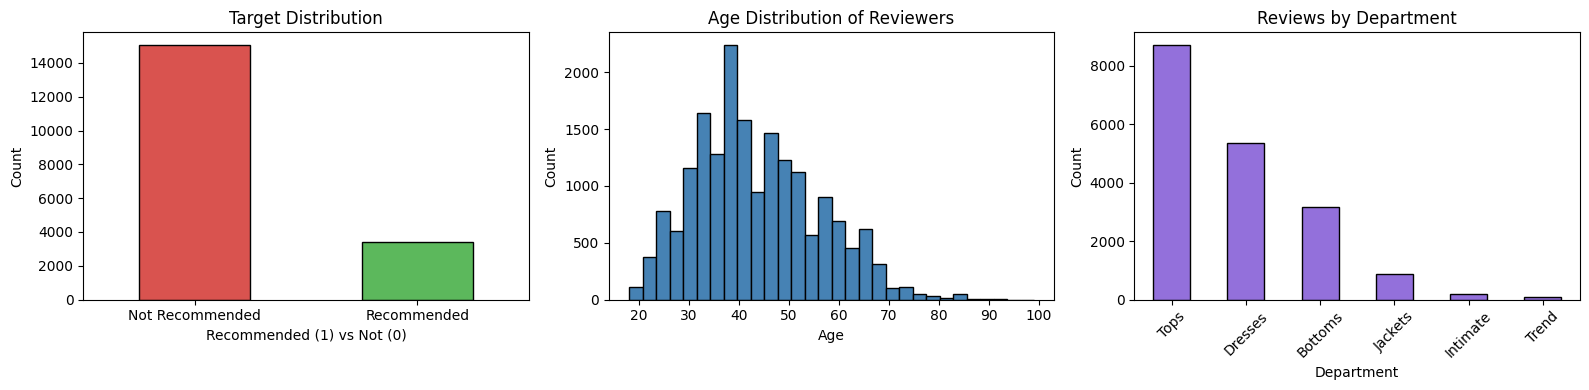

In [6]:
# Visualizations for data exploration

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Target distribution
df['Recommended IND'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#d9534f', '#5cb85c'], edgecolor='black'
)
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('Recommended (1) vs Not (0)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Not Recommended', 'Recommended'], rotation=0)

# 2. Age distribution
df['Age'].plot(kind='hist', ax=axes[1], bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('Age Distribution of Reviewers')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

# 3. Reviews by Department
df['Department Name'].value_counts().plot(
    kind='bar', ax=axes[2], color='mediumpurple', edgecolor='black'
)
axes[2].set_title('Reviews by Department')
axes[2].set_xlabel('Department')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Building Pipeline

In [7]:
# ── Building Pipeline ─────────────────────────────────────────────────────────

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

# Define feature columns by type
numerical_features = ['Age', 'Positive Feedback Count']
categorical_features = ['Clothing ID', 'Division Name', 'Department Name', 'Class Name']
text_features = 'Review Text'

print("Feature columns defined:")
print(f"  Numerical:   {numerical_features}")
print(f"  Categorical: {categorical_features}")
print(f"  Text:        {text_features}")

Feature columns defined:
  Numerical:   ['Age', 'Positive Feedback Count']
  Categorical: ['Clothing ID', 'Division Name', 'Department Name', 'Class Name']
  Text:        Review Text


In [8]:
# ── Custom Transformers ───────────────────────────────────────────────────────

class TextSelector(BaseEstimator, TransformerMixin):
    """Selects a single text column from a DataFrame and returns it as a Series."""
    def __init__(self, column):
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.column]


class SpacyLemmatizer(BaseEstimator, TransformerMixin):
    """Lemmatizes text using spaCy, removing stop words."""
    def __init__(self, nlp):
        self.nlp = nlp

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return [
            ' '.join([token.lemma_ for token in doc if not token.is_stop])
            for doc in self.nlp.pipe(X, batch_size=50)
        ]


class CharacterCounter(BaseEstimator, TransformerMixin):
    """Counts occurrences of a specific character in each text."""
    def __init__(self, char):
        self.char = char

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return np.array([text.count(self.char) for text in X]).reshape(-1, 1)


print("Custom transformers defined successfully!")

Custom transformers defined successfully!


In [10]:
# ── Assemble Full Pipeline ────────────────────────────────────────────────────

# 1. Numerical branch: impute missing values, then scale to 0-1
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler()),
])

# 2. Categorical branch: impute missing, then one-hot encode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

# 3. Text branch: lemmatize with spaCy, then TF-IDF vectorize
tfidf_pipeline = Pipeline([
    ('lemmatizer', SpacyLemmatizer(nlp=nlp)),
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=500)),
])

# 4. Combine all branches with ColumnTransformer
preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, numerical_features),
    ('categorical', categorical_pipeline, categorical_features),
    ('tfidf', tfidf_pipeline, text_features),
    ('exclamations', CharacterCounter('!'), text_features),
    ('questions', CharacterCounter('?'), text_features),
    ('commas', CharacterCounter(','), text_features),
], remainder='drop')

# 5. Full pipeline: preprocessor + model
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42)),
])

print("Full pipeline assembled successfully!")
print(full_pipeline)

Full pipeline assembled successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['Age',
                                                   'Positive Feedback Count']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHo

## Training Pipeline

In [11]:
# ── Training Pipeline ─────────────────────────────────────────────────────────

# Train the pipeline on training data only
print("Training pipeline... (this may take 1-2 minutes due to spaCy lemmatization)")
full_pipeline.fit(X_train, y_train)
print("Training complete!")

Training pipeline... (this may take 1-2 minutes due to spaCy lemmatization)
Training complete!


Test Accuracy: 0.8515 (85.1%)

Classification Report:
                 precision    recall  f1-score   support

Not Recommended       0.73      0.26      0.38       327
    Recommended       0.86      0.98      0.92      1518

       accuracy                           0.85      1845
      macro avg       0.79      0.62      0.65      1845
   weighted avg       0.84      0.85      0.82      1845



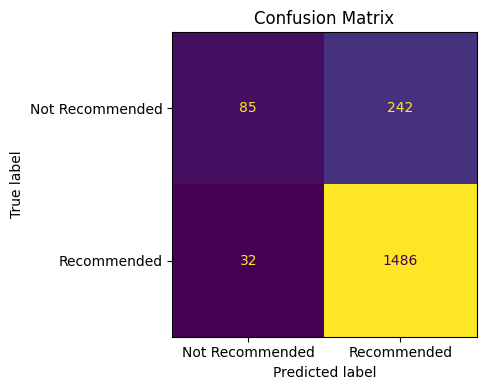

In [13]:
# ── Model Evaluation ──────────────────────────────────────────────────────────

# Predict on test data (pipeline applies same transformations automatically)
y_pred = full_pipeline.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy:.1%})")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Recommended', 'Recommended']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not Recommended', 'Recommended'],
    ax=ax,
    colorbar=False
)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

## Fine-Tuning Pipeline

In [14]:
# ── Fine-Tuning Pipeline ──────────────────────────────────────────────────────

# Use RandomizedSearchCV to find the best hyperparameters
# Parameters are referenced with double underscore: step__parameter
param_distributions = {
    'classifier__n_estimators': [100, 150, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__max_features': ['sqrt', 'log2'],
    'preprocessor__tfidf__tfidf__max_features': [300, 500],
}

random_search = RandomizedSearchCV(
    full_pipeline,
    param_distributions=param_distributions,
    n_iter=6,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

print("Running RandomizedSearchCV with 5-fold cross-validation...")
print("(This will take several minutes)")
random_search.fit(X_train, y_train)
print("\nSearch complete!")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation accuracy: {random_search.best_score_:.4f} ({random_search.best_score_:.1%})")

Running RandomizedSearchCV with 5-fold cross-validation...
(This will take several minutes)
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Search complete!
Best parameters: {'preprocessor__tfidf__tfidf__max_features': 300, 'classifier__n_estimators': 150, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 20}
Best cross-validation accuracy: 0.8353 (83.5%)


Final Test Accuracy (best model): 0.8396 (84.0%)
Baseline model accuracy:          0.8515 (85.1%)
Improvement:                      -1.2%

Final Classification Report:
                 precision    recall  f1-score   support

Not Recommended       0.80      0.13      0.22       327
    Recommended       0.84      0.99      0.91      1518

       accuracy                           0.84      1845
      macro avg       0.82      0.56      0.56      1845
   weighted avg       0.83      0.84      0.79      1845



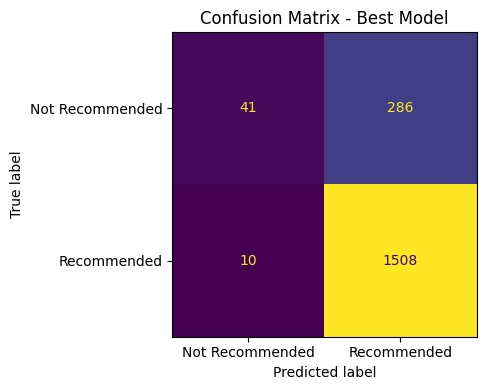

In [15]:
# ── Final Evaluation with Best Model ─────────────────────────────────────────

# Get the best pipeline from the search
best_pipeline = random_search.best_estimator_

# Predict on test data using the best pipeline
y_pred_best = best_pipeline.predict(X_test)

# Final accuracy
final_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Final Test Accuracy (best model): {final_accuracy:.4f} ({final_accuracy:.1%})")
print(f"Baseline model accuracy:          0.8515 (85.1%)")
print(f"Improvement:                      {final_accuracy - 0.8515:+.1%}")

# Detailed classification report
print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Not Recommended', 'Recommended']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['Not Recommended', 'Recommended'],
    ax=ax,
    colorbar=False
)
ax.set_title('Confusion Matrix - Best Model')
plt.tight_layout()
plt.show()